<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/softmax_binomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio del Algoritmo Softmax en el Problema del Bandido Multibrazo (Distribución Binomial)

*Description:* Este último análisis evalúa el comportamiento del algoritmo **Softmax** frente a un entorno donde las recompensas provienen de brazos de naturaleza Binomial. La distribución Binomial representa el número de éxitos en $n$ ensayos independientes, aportando simultáneamente mayor magnitud de recompensa y mayor amplitud de varianza que su contraparte de Bernoulli.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/28

This software is licensed under the GNU General Public License v3.0 (GPL-3.0).

## 1. Marco Teórico: Varianza y Competición Subóptima



La distribución Binomial $B(n, p)$ puede entenderse como la suma de $n$ distribuciones Bernoulli independientes. Si $n=10$, los valores posibles de recompensa en un solo paso oscilan en el rango discreto $[0, 10]$.

Debido a esto, la magnitud de la recompensa esperada ($Q = n \cdot p$) y las diferencias absolutas entre brazos son considerablemente mayores. Si el mejor brazo tiene $p=0.8$ ($Q=8$) y el segundo mejor tiene $p=0.6$ ($Q=6$), la diferencia a exponenciar en la fórmula de Softmax es amplia. Como resultado, emplear hiperparámetros de temperatura pequeños (adecuados para Bernoulli) resultaría en una explotación miope extrema. Se requerirán **temperaturas superiores** ($\tau > 0.5$) para asegurar una exploración sistemática inicial ante una varianza estocástica abultada.

## 2. Preparación del Entorno

In [ ]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git


fatal: destination path 'FernandezMartinezPolo-EML-RL' already exists and is not an empty directory.


In [ ]:
%cd FernandezMartinezPolo-EML-RL/k_brazos

/content/FernandezMartinezPolo-EML-RL/k_brazos


In [ ]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/FernandezMartinezPolo-EML-RL/k_brazos/src')
sys.path.append('./src')

# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', './src']


In [ ]:
def run_experiment(bandit: Bandit, algorithms: List[Softmax], steps: int, runs: int):
    optimal_arm = bandit.optimal_arm
    n_algos = len(algorithms)
    rewards = np.zeros((n_algos, steps))
    regrets = np.zeros((n_algos, steps))
    optimal_selections = np.zeros((n_algos, steps))
    np.random.seed(42)
    arm_stats = [{'mean_rewards': np.zeros(bandit.k), 'selections': np.zeros(bandit.k)} for _ in algorithms]

    print(f"Iniciando simulación: {runs} iteraciones independientes de {steps} pasos...")

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)
        for algo in algorithms:
            algo.reset()
        sum_current_run_expected_value = np.zeros(n_algos)

        for idx, algo in enumerate(algorithms):
            for step in range(steps):
                chosen_arm = algo.select_arm()
                reward = current_bandit.pull_arm(chosen_arm)

                arm_stats[idx]['mean_rewards'][chosen_arm] += reward
                arm_stats[idx]['selections'][chosen_arm] += 1
                algo.update(chosen_arm, reward)
                rewards[idx, step] += reward

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] += bandit.get_expected_value(chosen_arm)

                regrets[idx, step] += (step + 1) * bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs
    optimal_selections = (optimal_selections / runs) * 100
    for stat in arm_stats:
        stat['mean_rewards'] /= runs
        stat['selections'] /= runs

    return rewards, regrets, optimal_selections, arm_stats

## 3. Diseño Experimental

El entorno constará de 10 brazos configurados bajo la distribución Binomial. Para acomodar adecuadamente el escalado intrínseco de los valores $Q$ (con ensayos que aumentan el retorno potencial esperado), se eleva significativamente el rango de exploración paramétrica evaluando las siguientes temperaturas:
* $\tau=0.5$ (Explotación predominante)
* $\tau=1.0$ (Balance medio-bajo)
* $\tau=2.0$ (Balance medio-alto)
* $\tau=5.0$ (Exploración pura/uniforme)

In [ ]:
seed = 42
np.random.seed(seed)

k = 10
steps = 2000
runs = 500

# Creación del entorno (Distribución Binomial)
bandit = Bandit(arms=ArmBinomial.generate_arms(k=k))
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"\\nBrazo Óptimo Teórico: {optimal_arm + 1} (Recompensa Esperada: {bandit.get_expected_value(optimal_arm):.4f})")

# Algoritmos a comparar (Escala de temperatura mayor)
algorithms = [
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=1.0),
    Softmax(k=k, tau=2.0),
    Softmax(k=k, tau=5.0)
]

rewards, regrets, optimal_selections, arm_stats = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=7, p=0.80), ArmBinomial(n=8, p=0.60), ArmBinomial(n=7, p=0.45), ArmBinomial(n=7, p=0.06), ArmBinomial(n=8, p=0.33), ArmBinomial(n=8, p=0.71), ArmBinomial(n=6, p=0.06), ArmBinomial(n=8, p=0.83), ArmBinomial(n=6, p=0.00), ArmBinomial(n=5, p=0.62)
\nBrazo Óptimo Teórico: 8 (Recompensa Esperada: 6.6400)
Iniciando simulación: 500 iteraciones independientes de 2000 pasos...


## 4. Visualización de Resultados

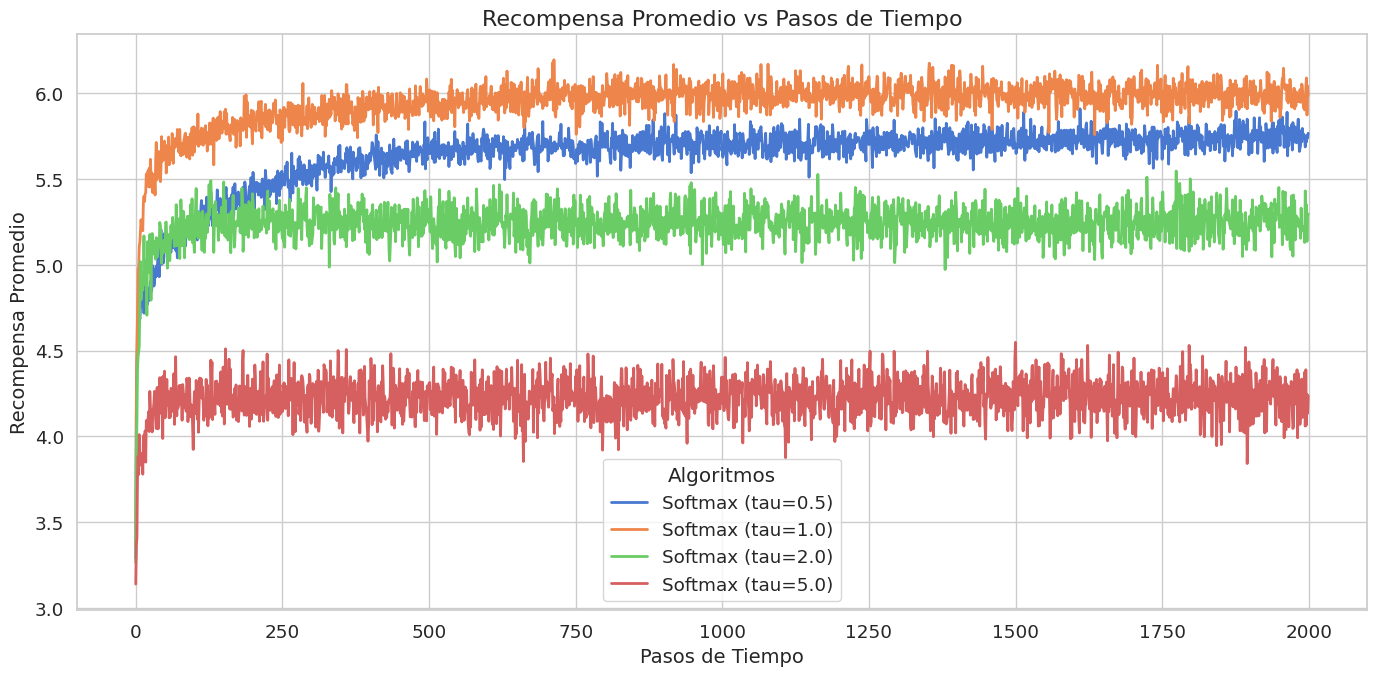

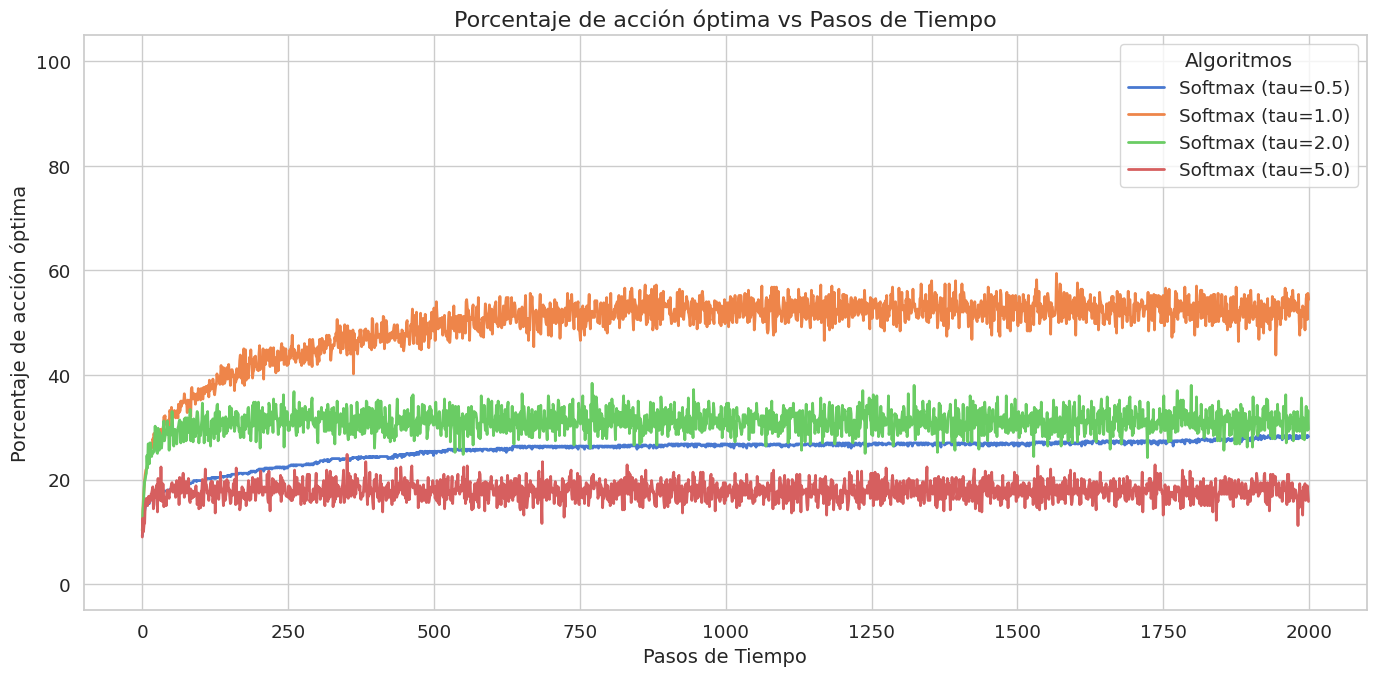

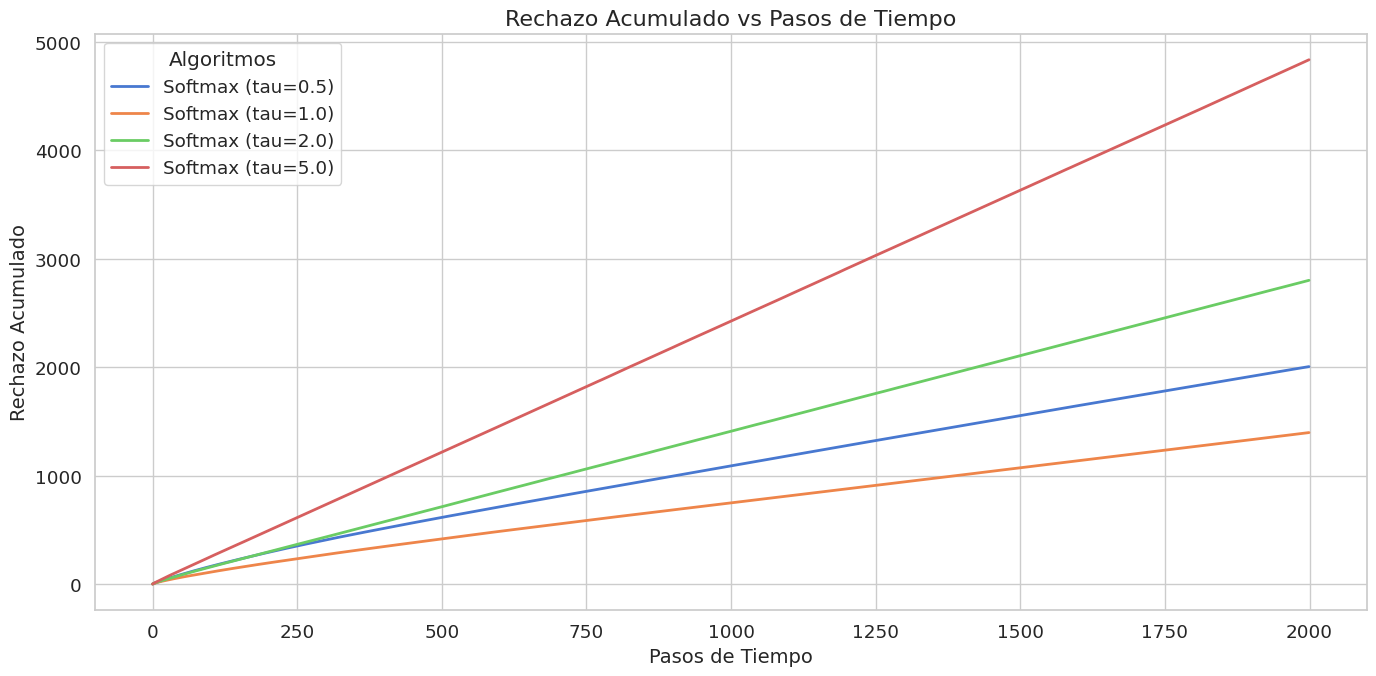

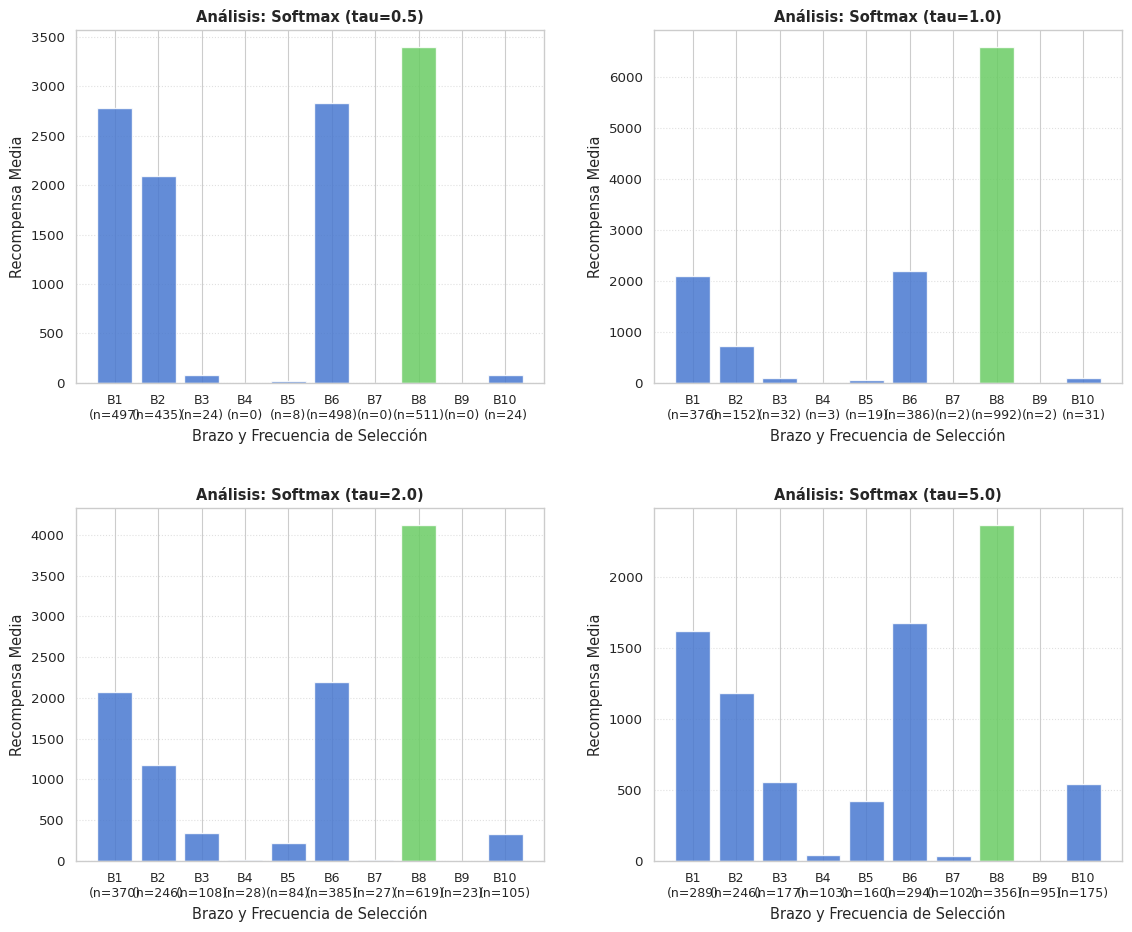

In [ ]:
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regrets, algorithms)
plot_arm_statistics(arm_stats, algorithms, k, optimal_arm)

## 5. Análisis y Discusión

### 5.1. Recompensa Promedio y Lamento Acumulado
Las recompensas binomiales, por su varianza intrínseca, obligan a una lectura cuidadosa. La configuración muy exploratoria ($\tau=5.0$) exhibe un lamento acumulado completamente lineal, un síntoma clásico de que el agente sigue escogiendo acciones subóptimas y aleatorias perpetuamente. Por el contrario, las temperaturas moderadas ($\tau=1.0$ y $\tau=2.0$) exhiben curvas de lamento que se aplanan majestuosamente tras el periodo de calentamiento inicial, reflejando una retención magistral del aprendizaje.

### 5.2. Ganancia y nº de selecciones
El análisis estructural de las selecciones de brazo vuelve a revelar la elegancia de la regla de Boltzmann en Softmax. En el caso de $\tau=1.0$, los brazos con rendimientos medios/bajos son descartados casi por completo. Las escasas selecciones "exploratorias" fuera del brazo óptimo se destinan casi exclusivamente al segundo mejor brazo. Esto demuestra cómo Softmax explora inteligentemente con base en méritos y proximidad al valor $Q$ máximo, a diferencia de los métodos rígidos e indiferenciados.

### 5.3. Velocidad de Convergencia
La distribución discreta pero variada de la Binomial produce convergencias peculiares.
* Las configuraciones agresivas como $\tau=0.5$ pueden converger algo más rápido en los casos favorables, pero son propensas a quedar ancladas si un brazo mediocre encadena varios "éxitos múltiples".
* La estabilidad reside en $\tau=2.0$, que si bien presenta una fase inicial de convergencia de aprendizaje más parsimoniosa (más lenta que $\tau=1.0$), asegura invariablemente atrapar el pico probabilístico a largo plazo minimizando severamente las recaídas.

### 5.4. Interpretación práctica
Ante entornos discretos de amplia varianza (como los escenarios de logística, inventariado de almacén o campañas multicanal), una estrategia de exploración es la decisión más robusta. Los resultados sugieren firmemente que el algoritmo Softmax brilla cuando se le permite explorar sin penalizaciones bruscas; una temperatura lo suficientemente amplia protege al agente contra el engaño de las fluctuaciones estocásticas tempranas y asegura la dominancia asintótica en la recompensa acumulada.